In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import joblib
print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [9]:
print("Shape of Dataset")
print(df.shape)
print("\nColumn Names")
print(df.columns)
print("\nInformation")
df.info()

Shape of Dataset
(2640, 12)

Column Names
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   flo

In [10]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [11]:
df.isnull().sum()
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)
print(df["Region"].value_counts())
print()
print(df["Model"].value_counts())
print()
print(df["Source_Type"].value_counts())

0
(2640, 12)
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


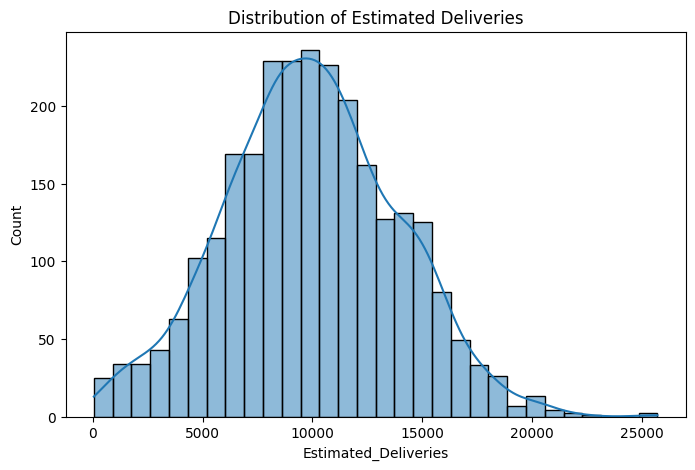

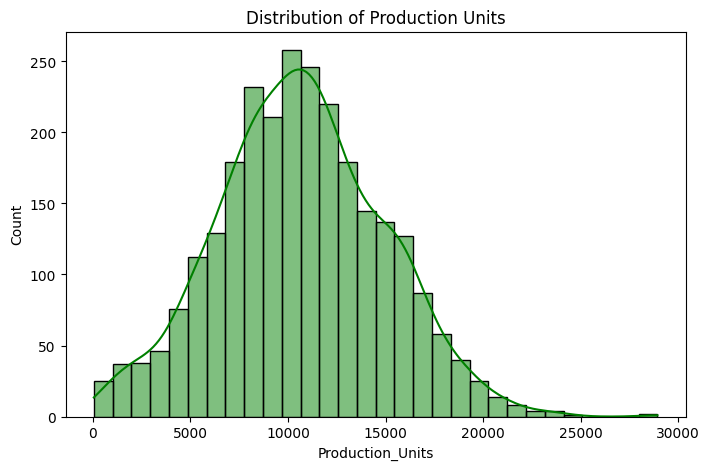

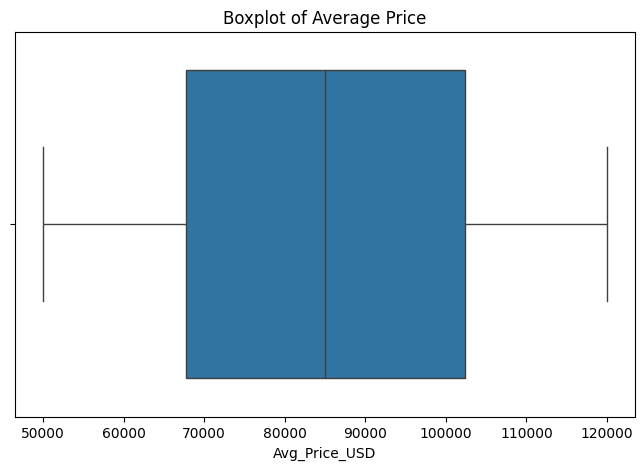

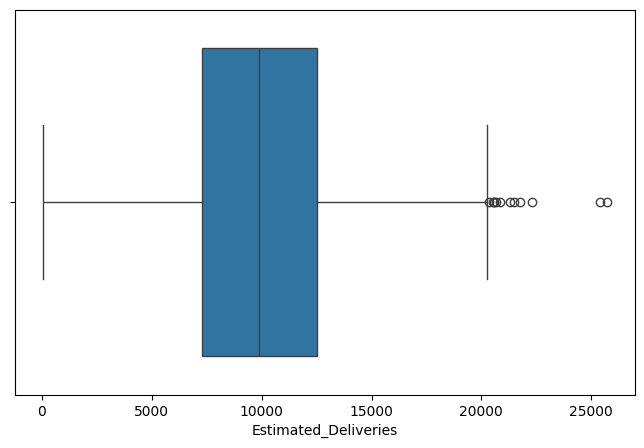

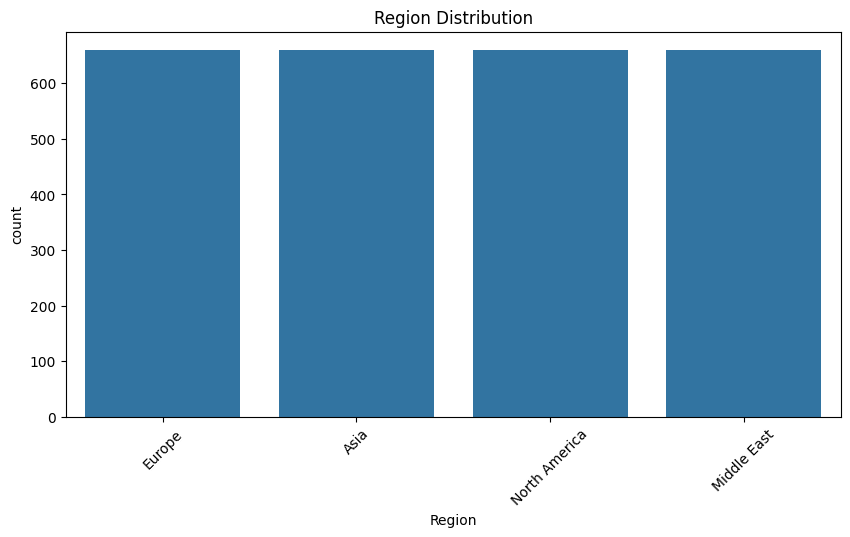

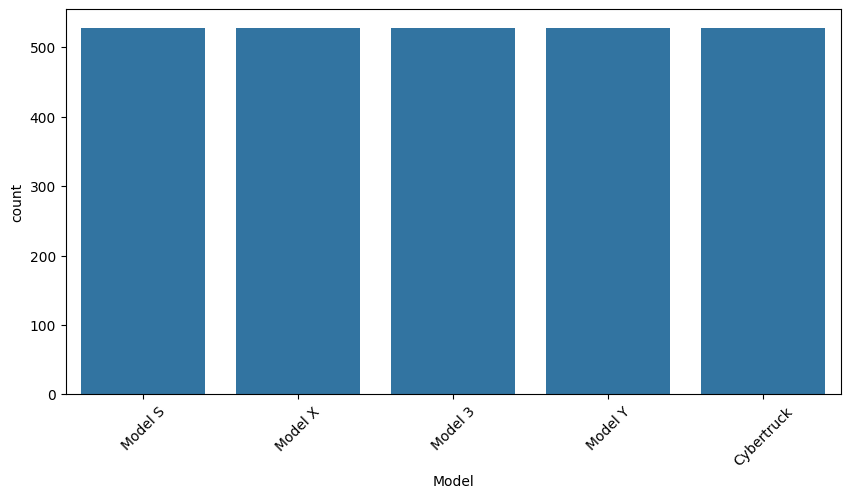

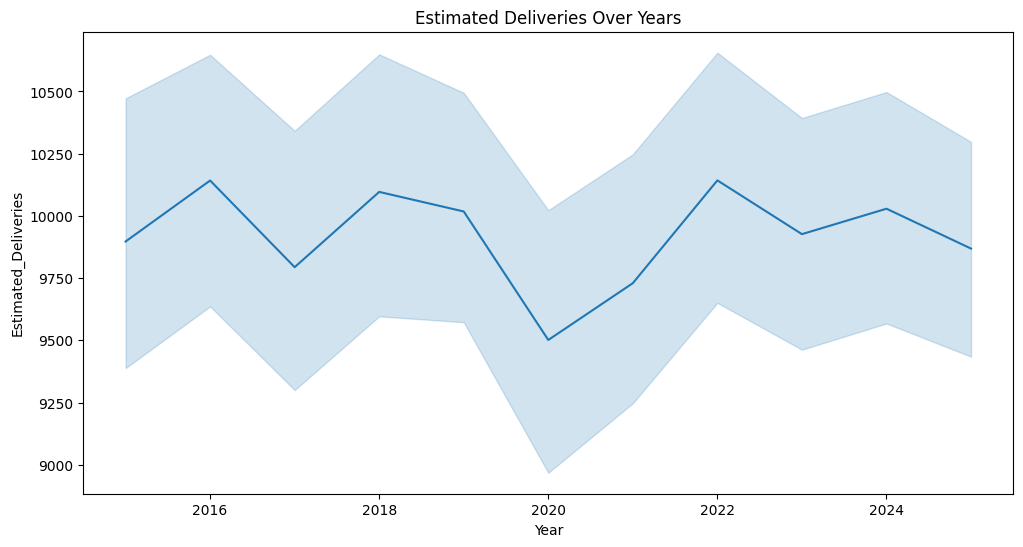

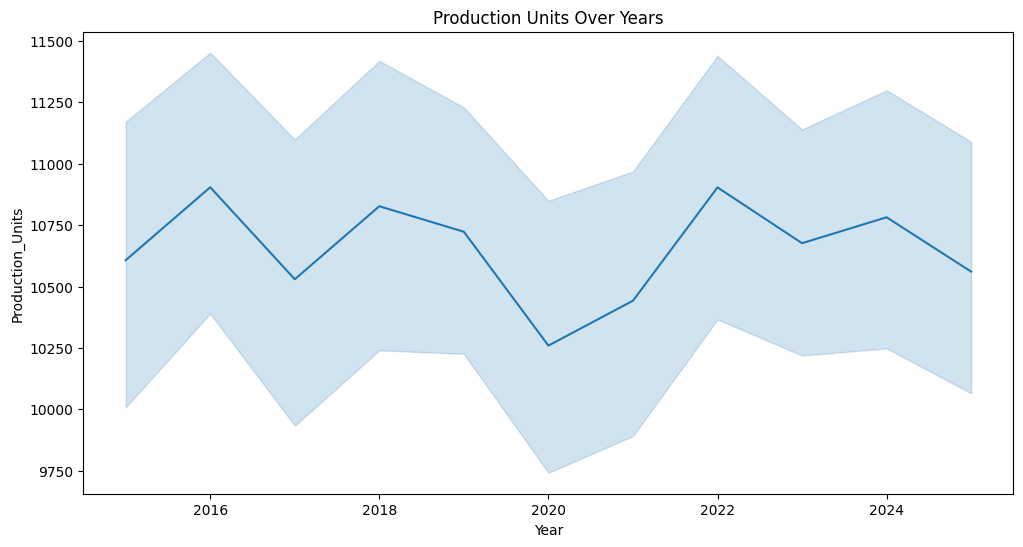

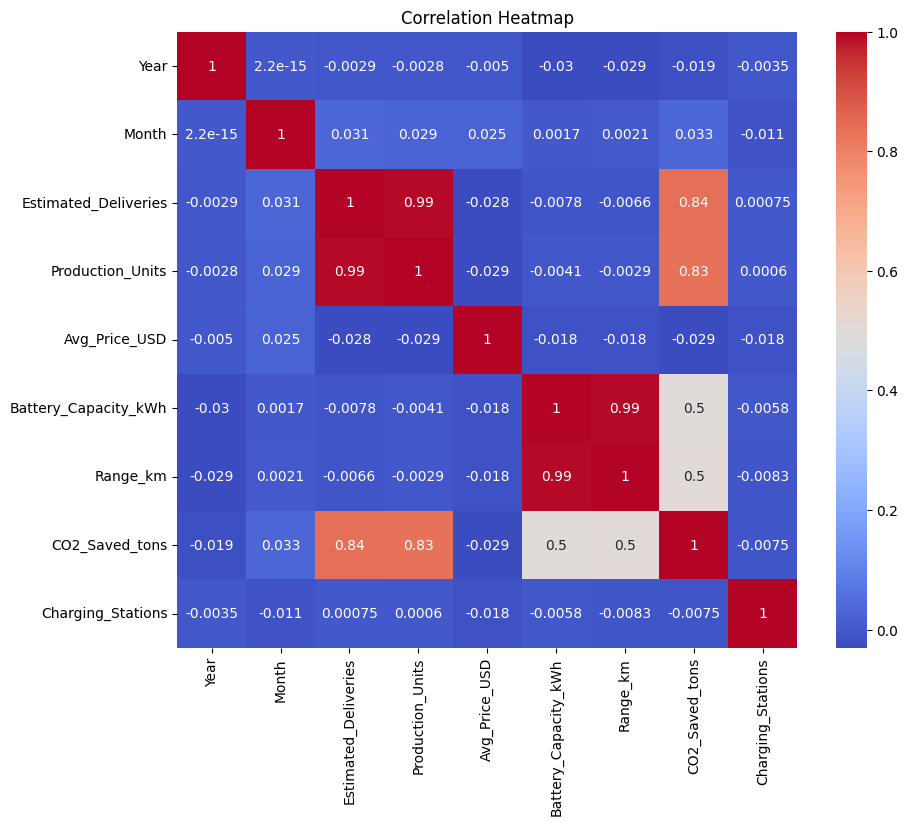

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Production_Units"], bins=30, color="green", kde=True)
plt.title("Distribution of Production Units")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Avg_Price_USD"])
plt.title("Boxplot of Average Price")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Estimated_Deliveries"])
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Region")
plt.xticks(rotation=45)
plt.title("Region Distribution")
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Model")
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(12,6))
sns.lineplot(data=df,
             x="Year",
             y="Estimated_Deliveries")
plt.title("Estimated Deliveries Over Years")
plt.show()
plt.figure(figsize=(12,6))
sns.lineplot(data=df,
             x="Year",
             y="Production_Units")
plt.title("Production Units Over Years")
plt.show()
plt.figure(figsize=(10,8))
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [13]:
target = "Estimated_Deliveries"
X = df.drop(columns=[target])
y = df[target]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
print("Categorical Columns")
print(categorical_features)
print()
print("Numerical Columns")
print(numerical_features)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ],
    remainder="passthrough"
)

Features Shape : (2640, 11)
Target Shape : (2640,)
Categorical Columns
['Region', 'Model', 'Source_Type']

Numerical Columns
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (2112, 11)
Testing Samples : (528, 11)


In [15]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully")
linear_predictions = linear_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, linear_predictions)
mse = mean_squared_error(y_test, linear_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linear_predictions)
print("Linear Regression Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Linear Regression Model Trained Successfully
Linear Regression Performance
MAE : 309.7036740991358
MSE : 147478.36137698343
RMSE : 384.02911527250563
R2 Score : 0.9901062987611021


In [16]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
ridge_predictions = ridge_pipeline.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)
print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("R2 :", ridge_r2)

Ridge Regression
MAE : 309.70334530056596
RMSE : 384.0258908615651
R2 : 0.9901064649007166


In [17]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])
lasso_pipeline.fit(X_train, y_train)
lasso_predictions = lasso_pipeline.predict(X_test)
lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))
lasso_r2 = r2_score(y_test, lasso_predictions)
print("Lasso Regression")
print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)
print("R2 :", lasso_r2)

Lasso Regression
MAE : 309.6937973449594
RMSE : 383.979713826566
R2 : 0.9901088440457707


In [18]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE":[
        mae,
        ridge_mae,
        lasso_mae
    ],
    "RMSE":[
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2 Score":[
        r2,
        ridge_r2,
        lasso_r2
    ]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,309.703674,384.029115,0.990106
1,Ridge Regression,309.703345,384.025891,0.990106
2,Lasso Regression,309.693797,383.979714,0.990109


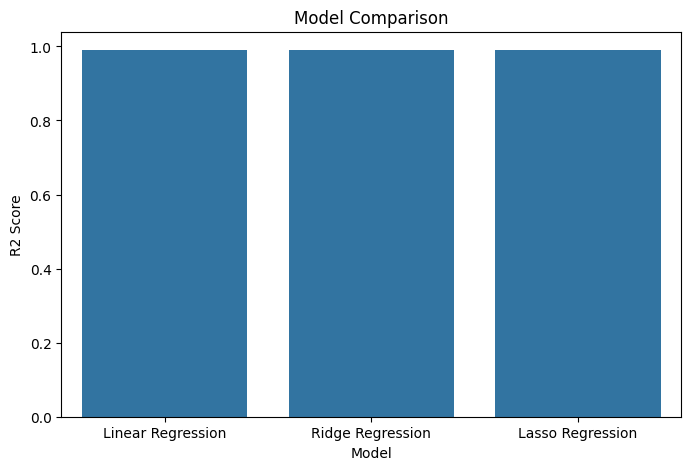

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)
plt.title("Model Comparison")
plt.show()

In [20]:
ridge_grid = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])
parameters = {
    "model__alpha":[0.01,0.1,1,10,100]
}
grid = GridSearchCV(
    ridge_grid,
    parameters,
    cv=5,
    scoring="r2"
)
grid.fit(X_train,y_train)
print("Best Parameters")
print(grid.best_params_)
print()
print("Best Score")
print(grid.best_score_)

Best Parameters
{'model__alpha': 100}

Best Score
0.9902297002752117


(2112, 14)
(528, 14)
Forecast MAE : 2929.8184356253364
Forecast RMSE : 3646.4169273352923
Forecast R2 : -6.192039929064919e-05


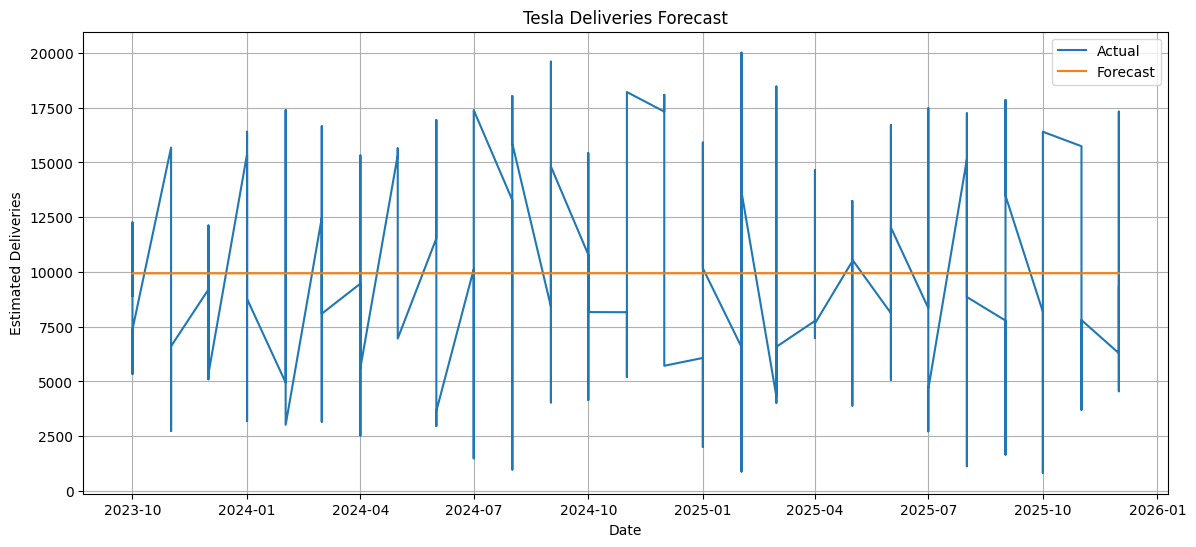

In [21]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)
df.head()
df = df.sort_values("Date")
df = df.reset_index(drop=True)
df[["Date","Estimated_Deliveries"]].head()
df["Time_Index"] = np.arange(len(df))
df.head()
split = int(len(df)*0.80)
train = df.iloc[:split]
test = df.iloc[split:]
print(train.shape)
print(test.shape)
X_train_ts = train[["Time_Index"]]
y_train_ts = train["Estimated_Deliveries"]
X_test_ts = test[["Time_Index"]]
y_test_ts = test["Estimated_Deliveries"]
forecast_model = LinearRegression()
forecast_model.fit(X_train_ts,y_train_ts)
forecast = forecast_model.predict(X_test_ts)
forecast[:10]
mae_ts = mean_absolute_error(y_test_ts,forecast)
rmse_ts = np.sqrt(mean_squared_error(y_test_ts,forecast))
r2_ts = r2_score(y_test_ts,forecast)
print("Forecast MAE :",mae_ts)
print("Forecast RMSE :",rmse_ts)
print("Forecast R2 :",r2_ts)
plt.figure(figsize=(14,6))
plt.plot(
    test["Date"],
    y_test_ts,
    label="Actual"
)
plt.plot(
    test["Date"],
    forecast,
    label="Forecast"
)
plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
joblib.dump(
    ridge_pipeline,
    "tesla_delivery_prediction_model.pkl"
)
print("Model Saved Successfully")
saved_model = joblib.load(
    "tesla_delivery_prediction_model.pkl"
)
print(saved_model)

Model Saved Successfully
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', Ridge())])


In [23]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Lasso Regression,309.693797,383.979714,0.990109
1,Ridge Regression,309.703345,384.025891,0.990106
0,Linear Regression,309.703674,384.029115,0.990106
